# Evaluate RAG

## 1. Imports & Setup

All imports are consolidated here. Paths are configured, environment variables loaded, and `experiments` is added to `sys.path` so we can import `utils.models` and `utils.prompts`.

*Run the setup cell below before continuing.*

In [1]:
# --- Standard library ---
import json
import random
import sys
from collections import defaultdict
from pathlib import Path

# --- Third-party ---
from dotenv import load_dotenv
from tenacity import retry, wait_exponential

from chromadb import PersistentClient
from litellm import completion
from openai import OpenAI
from pydantic import BaseModel, Field
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tabulate import tabulate

wait = wait_exponential(multiplier=1, min=10, max=240)

# --- Path setup (find backend/data/vector_db; works from repo root or experiments/notebooks) ---
_cwd = Path.cwd()
_candidates = [_cwd, _cwd.parent, _cwd.parent.parent]
VECTOR_DB_PATH = None
for root in _candidates:
    p = root / "backend" / "data" / "vector_db"
    if p.exists():
        VECTOR_DB_PATH = p
        break
if VECTOR_DB_PATH is None:
    VECTOR_DB_PATH = _cwd / "backend" / "data" / "vector_db"

EXPERIMENTS_PATH = VECTOR_DB_PATH.parent.parent.parent / "experiments"  # experiments/
BACKEND_PATH = VECTOR_DB_PATH.parent.parent  # backend/

if str(EXPERIMENTS_PATH) not in sys.path:
    sys.path.insert(0, str(EXPERIMENTS_PATH))

# Load environment variables from backend/.env if it exists;
# otherwise, load system environment variables with default behavior
env_path = BACKEND_PATH / ".env"
if env_path.exists():
    load_dotenv(env_path, override=True)
    print(f"[OK] Loaded environment variables from {env_path}")
else:
    load_dotenv(override=True)
    print("[WARNING] Backend .env not found, using default environment")


[OK] Loaded environment variables from c:\Users\smvan\repos\madetech-rag-assistant\backend\.env


In [2]:
# --- Project imports (after path is set) ---
from utils.models import AnswerEval, QAPairWithTS, Result
from utils.prompts import (
    EVALUATE_ANSWER_SYSTEM_PROMPT,
    RAG_SYSTEM_PROMPT,
    RERANK_CHUNKS_SYSTEM_PROMPT,
    REWRITE_QUERY_SYSTEM_PROMPT,
)

# --- Constants ---
COLLECTION_NAME = "docs"
EMBEDDING_MODEL = "text-embedding-3-large"

print(f"DB path: {VECTOR_DB_PATH}")
print(f"Exists: {VECTOR_DB_PATH.exists()}")

DB path: c:\Users\smvan\repos\madetech-rag-assistant\backend\data\vector_db
Exists: True


## 2. Connect to ChromaDB

Open the vector database and verify the collection.

---

In [3]:
# Connect to ChromaDB and verify the collection
chroma = PersistentClient(path=str(VECTOR_DB_PATH))
collection = chroma.get_collection(COLLECTION_NAME)
print(f"Collection '{COLLECTION_NAME}' has {collection.count()} chunks")

Collection 'docs' has 1637 chunks


## 3. Experiment Parameters

Define the four experiment variants and evaluation settings. Adjust `n_questions` to evaluate more or fewer questions (use `None` for all). When `n_questions` is set, questions are randomly sampled using `random_seed` for reproducibility.

In [4]:
from datetime import datetime

EXPERIMENT_PARAMS = {
    "experiments": [
        {"name": "basic_rag", "use_query_rewriting": False, "use_reranking": False},
        {"name": "with_reranking", "use_query_rewriting": False, "use_reranking": True},
        {"name": "with_rewriting", "use_query_rewriting": True, "use_reranking": False},
        {"name": "with_rewriting_and_reranking", "use_query_rewriting": True, "use_reranking": True},
    ],
    "n_questions": 15,  # or None for all
    "random_seed": 42,  # for reproducible random sampling when n_questions is set
    "output_dir": EXPERIMENTS_PATH / "output" / "rerank_rewrite_experiments",
    "retrieval_k": 20,
    "final_k": 10,
    "model": "groq/openai/gpt-oss-20b",
}

## 3. Basic Retrieval (Semantic Search)

Embed a query, retrieve the top-k similar chunks, and inspect results. This tests retrieval without using an LLM.

In [5]:
# Test semantic search: embed query and retrieve similar chunks
client = OpenAI()
query = "What cycling benefits do we have?"
query_embedding = client.embeddings.create(
    model=EMBEDDING_MODEL, input=[query]
).data[0].embedding

results = collection.query(
    query_embeddings=[query_embedding],
    n_results=10,
    include=["documents", "metadatas", "distances"],
)

print(f"Query: {query}\n")
for i, (doc, meta, dist) in enumerate(zip(
    results["documents"][0],
    results["metadatas"][0],
    results["distances"][0],
), 1):
    print(f"--- Result {i} (distance={dist:.4f}) ---")
    print(f"Metadata: {meta}")
    print(f"Content preview: {doc[:200]}...")
    print()

Query: What cycling benefits do we have?

--- Result 1 (distance=0.9271) ---
Metadata: {'id': 'benefits-cycle_to_work_scheme', 'category': 'Benefits', 'title': 'Cycle To Work'}
Content preview: Headline: CycleScheme Benefits
Summary: CycleScheme provides cost-effective cycling equipment via salary sacrifice, saving 25‑39% on tax and NI, with monthly deductions over 12 months and no large upf...

--- Result 2 (distance=1.0282) ---
Metadata: {'category': 'Benefits', 'title': 'Cycle To Work', 'id': 'benefits-cycle_to_work_scheme'}
Content preview: Headline: Cycle To Work Overview
Summary: Made Tech offers a Cycle to Work scheme using CycleScheme up to £2500, allowing employees to hire a bike and accessories via salary sacrifice over 12 months, ...

--- Result 3 (distance=1.1143) ---
Metadata: {'category': 'Benefits', 'id': 'benefits-cycle_to_work_scheme', 'title': 'Cycle To Work'}
Content preview: Headline: Comparison to Interest‑Free Finance
Summary: CycleScheme offers greater tax and NI

## 4. RAG Pipeline

Define the RAG pipeline: query rewriting, multi-query retrieval, chunk merging, LLM reranking, and answer generation.

### Run RAG

Quick test: ask a question and generate an answer.


In [6]:
# RAG components: client, retrieval params, and pipeline functions
openai = OpenAI()
RETRIEVAL_K = EXPERIMENT_PARAMS.get("retrieval_k", 10)
FINAL_K = EXPERIMENT_PARAMS.get("final_k", 7)
MODEL = EXPERIMENT_PARAMS.get("model", "groq/openai/gpt-oss-20b")

def fetch_context_unranked(question, n_results=None):
    n = n_results or RETRIEVAL_K
    query = openai.embeddings.create(model=EMBEDDING_MODEL, input=[question]).data[0].embedding
    results = collection.query(query_embeddings=[query], n_results=n)
    chunks = []
    for result in zip(results["documents"][0], results["metadatas"][0]):
        chunks.append(Result(page_content=result[0], metadata=result[1]))
    return chunks


@retry(wait=wait)
def rewrite_query(question, history=[]):
    """Rewrite the user's question to be a more specific question that is more likely to surface relevant content in the Knowledge Base."""
    message = REWRITE_QUERY_SYSTEM_PROMPT.format(history=history, question=question)
    response = completion(model=MODEL, messages=[{"role": "system", "content": message}])
    return response.choices[0].message.content

def merge_chunks(chunks_1, chunks_2):
    merged = chunks_1[:]
    existing = [chunk.page_content for chunk in chunks_1]
    for chunk in chunks_2:
        if chunk.page_content not in existing:
            merged.append(chunk)
    return merged

class RankOrder(BaseModel):
    order: list[int] = Field(
        description="The order of relevance of chunks, from most relevant to least relevant, by chunk id number"
    )


def _repair_concatenated_order(concatenated: int, n: int) -> list[int] | None:
    """Recover order from LLM output like 124936781011121314151617 when it forgets commas."""
    s = str(concatenated)
    result = []
    i = 0
    valid = set(range(1, n + 1))
    used = set()
    while i < len(s) and len(result) < n:
        one = int(s[i])
        two_val = int(s[i : i + 2]) if i + 1 < len(s) else None
        # Prefer 1 digit first so "12" -> [1,2] not [12]
        if one in valid and one not in used:
            result.append(one)
            used.add(one)

            i += 2
        else:
            return None
    return result if len(result) == n and i == len(s) else None


@retry(wait=wait)
def rerank(question, chunks):
    n = len(chunks)
    valid_ids = set(range(1, n + 1))
    system_prompt = RERANK_CHUNKS_SYSTEM_PROMPT
    user_prompt = f"The user has asked the following question:\n\n{question}\n\nOrder all {n} chunks by relevance, from most to least relevant. Include every chunk ID from 1 to {n} exactly once.\n\n"
    user_prompt += "Here are the chunks:\n\n"
    for index, chunk in enumerate(chunks):
        user_prompt += f"# CHUNK ID: {index + 1}:\n\n{chunk.page_content}\n\n"
    user_prompt += f"Reply with valid JSON only: {{\"order\": [a, b, c, ...]}} with {n} comma-separated integers."
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
    response = completion(model=MODEL, messages=messages, response_format=RankOrder)
    reply = response.choices[0].message.content
    parsed = RankOrder.model_validate_json(reply)
    order = parsed.order
    # Validate: must have n elements, each 1..n exactly once
    if len(order) == n and set(order) == valid_ids:
        return [chunks[i - 1] for i in order]
    # Repair: LLM sometimes returns concatenated numbers without commas, e.g. [124936781011121314151617]
    if len(order) == 1 and isinstance(order[0], int) and order[0] > 9:
        repaired = _repair_concatenated_order(order[0], n)
        if repaired is not None:
            return [chunks[i - 1] for i in repaired]
    return [chunks[i - 1] for i in list(range(1, n + 1))]  # fallback to original order

def fetch_context(original_question, history, config=None):
    """Retrieval pipeline with optional query rewriting and reranking.
    config: {use_query_rewriting: bool, use_reranking: bool, retrieval_k: int, final_k: int}
    """
    cfg = config or {}
    use_rewriting = cfg.get("use_query_rewriting", True)
    use_reranking = cfg.get("use_reranking", True)
    retrieval_k = cfg.get("retrieval_k", RETRIEVAL_K)
    final_k = cfg.get("final_k", FINAL_K)

    chunks1 = fetch_context_unranked(original_question, n_results=retrieval_k)
    if use_rewriting:
        rewritten_question = rewrite_query(original_question, history)
        chunks2 = fetch_context_unranked(rewritten_question, n_results=retrieval_k)
        chunks = merge_chunks(chunks1, chunks2)
    else:
        chunks = chunks1

    if use_reranking:
        chunks = rerank(original_question, chunks)[:final_k]
    else:
        chunks = chunks[:final_k]
    return chunks


def make_rag_messages(question, history, chunks):
    context = "\n\n---\n\n".join(
        f"Extract from ({chunk.metadata['category']}) — {chunk.metadata['title']}:\n{chunk.page_content}" for chunk in chunks
    )
    system_prompt = RAG_SYSTEM_PROMPT.format(context=context)
    return (
        [{"role": "system", "content": system_prompt}]
        + history
        + [{"role": "user", "content": question}]
    )

@retry(wait=wait)
def answer_question(question: str, history: list[dict] = [], config: dict | None = None) -> tuple[str, list]:
    """
    Answer a question using RAG and return the answer and the retrieved context.
    config: {use_query_rewriting, use_reranking, retrieval_k, final_k, model}
    """
    cfg = config or {}
    model = cfg.get("model", MODEL)
    chunks = fetch_context(question, history, config=cfg)
    messages = make_rag_messages(question, history, chunks)
    response = completion(model=model, messages=messages)
    return response.choices[0].message.content, chunks

In [7]:
answer, chunks = answer_question("What cycling benefits do I have?")
# print(answer)

## 5. Load Evaluation Questions

Load QA pairs from `validation.jsonl` (from the latest run in `00_questions_generation/output`).

In [8]:
# Load eval questions from validation.jsonl (latest timestamp in 00_questions_generation/output)
QUESTIONS_OUTPUT = EXPERIMENTS_PATH / "scripts" / "00_questions_generation" / "output"
_latest_dir = max((d for d in QUESTIONS_OUTPUT.iterdir() if d.is_dir()), key=lambda d: d.name)
EVAL_QUESTIONS_FILE = _latest_dir / "validation.jsonl"


def load_eval_questions() -> list[QAPairWithTS]:
    """Load eval questions from JSONL file."""
    questions = []
    with open(EVAL_QUESTIONS_FILE, "r", encoding="utf-8") as f:
        for line in f:
            data = json.loads(line.strip())
            questions.append(QAPairWithTS(**data))
    return questions


questions = load_eval_questions()
print(f"Loaded {len(questions)} questions from {EVAL_QUESTIONS_FILE}")

Loaded 195 questions from c:\Users\smvan\repos\madetech-rag-assistant\experiments\scripts\00_questions_generation\output\2026-03-05_07-47-14\validation.jsonl


In [9]:
questions[:3]

[QAPairWithTS(question='What steps must I take to lock my screen during the DSE/H&S training session, especially if I’m using multiple monitors?', answer='Before leaving your workstation, lock each monitor’s screen and enable automatic screen lock. If using multiple screens, make sure no confidential information is displayed on any of them and that the workstation remains off when idle.', question_type='multi-source', doc_metadata=[HandbookDocMetadata(id='guides-welfare-dse_hs_training', title='DSE & Health & Safety Training', category='Guides'), HandbookDocMetadata(id='guides-office-clear_desk_clear_screen', title='Clear Desk/Clear Screen', category='Guides')]),
 QAPairWithTS(question='What are the main responsibilities of a Delivery Director at Made Tech?', answer='A Delivery Director leads delivery across multiple clients, manages senior client relationships, oversees a portfolio with revenue over £10\u202fmillion, and ensures successful project execution, client delight, and team e

## 6. Answer Evaluation (LLM-as-Judge)

Evaluate each RAG answer using an LLM judge that scores accuracy, completeness, and relevance against the reference answer.

**Optional:** Set `LOAD_FROM_PATH` to a previous results directory (e.g. `EXPERIMENT_PARAMS["output_dir"] / "2026-03-08_12-00-00"`) to load saved results instead of re-running the evaluation.

In [10]:
# Set to a previous run directory to load results instead of re-running; set to None to run evaluation
LOAD_FROM_PATH = None  # e.g. EXPERIMENT_PARAMS["output_dir"] / "2026-03-08_12-00-00"

In [11]:
# LLM-as-judge: compare generated answer to reference and return structured scores
@retry(wait=wait)
def evaluate_answer(test: QAPairWithTS, config: dict | None = None) -> tuple[AnswerEval, str, list]:
    """
    Evaluate answer quality using LLM-as-a-judge.

    Args:
        test: QA pair with question and reference answer
        config: RAG config (use_query_rewriting, use_reranking, etc.) passed to answer_question

    Returns:
        Tuple of (AnswerEval object, generated_answer string, retrieved_docs list)
    """
    generated_answer, retrieved_docs = answer_question(test.question, config=config)

    user_prompt = (
        f"""The user has provided the following:
        
        [QUESTION BEGINS]
        {test.question}
        [QUESTION ENDS]

        [GENERATED ANSWER BEGINS]
        {generated_answer}
        [GENERATED ANSWER ENDS]

        [REFERENCE ANSWER BEGINS]
        {test.answer}
        [REFERENCE ANSWER ENDS]

        Reply with your feedback and your scores for accuracy, completeness, and relevance, nothing else."""
    )

    # LLM judge prompt
    judge_messages = [
        {
            "role": "system",
            "content": EVALUATE_ANSWER_SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ]

    # Call LLM judge with structured outputs (async)
    judge_response = completion(model=MODEL, messages=judge_messages, response_format=AnswerEval)

    answer_eval = AnswerEval.model_validate_json(judge_response.choices[0].message.content)

    return answer_eval, generated_answer, retrieved_docs


In [12]:
# Load from previous run or run evaluation
if LOAD_FROM_PATH is not None:
    with open(Path(LOAD_FROM_PATH) / "results.json", "r", encoding="utf-8") as f:
        all_results = json.load(f)
    df_summary = pd.read_csv(Path(LOAD_FROM_PATH) / "summary.csv")
    questions_slice = list(all_results.values())[0]  # for len() in results display
    print(f"Loaded results from {LOAD_FROM_PATH}")
else:
    # Base config shared across experiments
    base_config = {
        "retrieval_k": EXPERIMENT_PARAMS.get("retrieval_k", 10),
        "final_k": EXPERIMENT_PARAMS.get("final_k", 7),
        "model": EXPERIMENT_PARAMS.get("model", "groq/openai/gpt-oss-20b"),
    }

    # Slice questions (random sample when n_questions is set, for reproducibility use random_seed)
    n_q = EXPERIMENT_PARAMS.get("n_questions")
    seed = EXPERIMENT_PARAMS.get("random_seed", 42)
    if n_q is not None:
        rng = random.Random(seed)
        questions_slice = rng.sample(questions, min(n_q, len(questions)))
    else:
        questions_slice = questions

    # Run all 4 experiments
    all_results = {}
    for exp in tqdm(EXPERIMENT_PARAMS["experiments"], desc="Experiments"):
        name = exp["name"]
        exp_config = {**base_config, "use_query_rewriting": exp["use_query_rewriting"], "use_reranking": exp["use_reranking"]}
        all_results[name] = []
        for qa in tqdm(questions_slice, desc=name, leave=False):
            try:
                eval_result, generated_answer, retrieved_docs = evaluate_answer(qa, config=exp_config)
                all_results[name].append({
                    "question": qa.question,
                    "expected_answer": qa.answer,
                    "question_type": qa.question_type,
                    "generated_answer": generated_answer,
                    "accuracy": eval_result.accuracy,
                    "completeness": eval_result.completeness,
                    "relevance": eval_result.relevance,
                    "feedback": eval_result.feedback,
                })
            except Exception as e:
                all_results[name].append({
                    "question": qa.question,
                    "expected_answer": qa.answer,
                    "question_type": qa.question_type,
                    "generated_answer": None,
                    "accuracy": 0.0,
                    "completeness": 0.0,
                    "relevance": 0.0,
                    "feedback": str(e),
                    "error": str(e),
                })

Experiments:   0%|          | 0/4 [00:00<?, ?it/s]

basic_rag:   0%|          | 0/15 [00:00<?, ?it/s]

with_reranking:   0%|          | 0/15 [00:00<?, ?it/s]

with_rewriting:   0%|          | 0/15 [00:00<?, ?it/s]

with_rewriting_and_reranking:   0%|          | 0/15 [00:00<?, ?it/s]


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.



In [13]:
# Persist results to timestamped output folder (only when we ran evaluation, not when loading)
if LOAD_FROM_PATH is None:
    output_base = EXPERIMENT_PARAMS["output_dir"]
    run_ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    output_dir = output_base / run_ts
    output_dir.mkdir(parents=True, exist_ok=True)

    # Save full results
    results_path = output_dir / "results.json"
    with open(results_path, "w", encoding="utf-8") as f:
        json.dump(all_results, f, indent=2, ensure_ascii=False)
    print(f"Saved results to {results_path}")

    # Compute and save summary
    summary_rows = []
    for name, records in all_results.items():
        acc = [r["accuracy"] for r in records if r.get("accuracy") is not None]
        comp = [r["completeness"] for r in records if r.get("completeness") is not None]
        rel = [r["relevance"] for r in records if r.get("relevance") is not None]
        mean_acc = np.mean(acc) if acc else 0.0
        mean_comp = np.mean(comp) if comp else 0.0
        mean_rel = np.mean(rel) if rel else 0.0
        overall = (mean_acc + mean_comp + mean_rel) / 3.0
        summary_rows.append({"experiment": name, "mean_accuracy": mean_acc, "mean_completeness": mean_comp, "mean_relevance": mean_rel, "overall_score": overall})
    df_summary = pd.DataFrame(summary_rows)
    summary_path = output_dir / "summary.csv"
    df_summary.to_csv(summary_path, index=False)
    print(f"Saved summary to {summary_path}")

Saved results to c:\Users\smvan\repos\madetech-rag-assistant\experiments\output\rerank_rewrite_experiments\2026-03-08_17-32-51\results.json
Saved summary to c:\Users\smvan\repos\madetech-rag-assistant\experiments\output\rerank_rewrite_experiments\2026-03-08_17-32-51\summary.csv


## 7. Results

Summary statistics and visualizations of the evaluation scores.

In [14]:
# Summary table: experiments vs mean metrics
print("=" * 50)
print("   RAG Experiments — Summary Across Configurations   ")
print("=" * 50)
print(f"Questions evaluated per experiment: {len(questions_slice)}\n")
print(tabulate(df_summary, headers="keys", tablefmt="github", showindex=False, floatfmt=".2f"))
print()

# Best combination selection
best_row = df_summary.loc[df_summary["overall_score"].idxmax()]
print("Best configuration for this project:", best_row["experiment"])
print(f"  Mean accuracy: {best_row['mean_accuracy']:.2f} | completeness: {best_row['mean_completeness']:.2f} | relevance: {best_row['mean_relevance']:.2f}")

   RAG Experiments — Summary Across Configurations   
Questions evaluated per experiment: 15

| experiment                   |   mean_accuracy |   mean_completeness |   mean_relevance |   overall_score |
|------------------------------|-----------------|---------------------|------------------|-----------------|
| basic_rag                    |            4.73 |                4.40 |             4.67 |            4.60 |
| with_reranking               |            4.73 |                4.33 |             4.60 |            4.56 |
| with_rewriting               |            4.47 |                4.20 |             4.47 |            4.38 |
| with_rewriting_and_reranking |            4.80 |                4.40 |             4.73 |            4.64 |

Best configuration for this project: with_rewriting_and_reranking
  Mean accuracy: 4.80 | completeness: 4.40 | relevance: 4.73


C:\Users\smvan\AppData\Local\Temp\ipykernel_44364\3190727693.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")


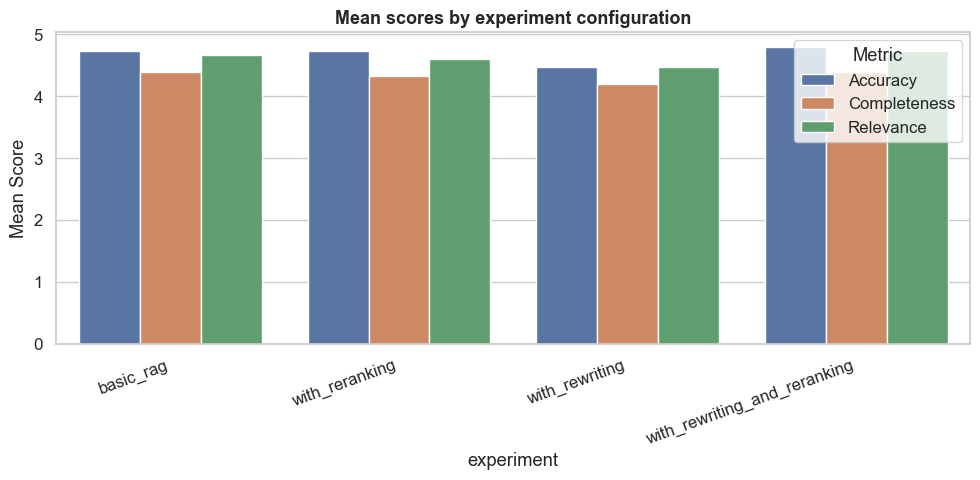

In [15]:
# Bar chart: compare mean scores across experiments
df_melt = df_summary.melt(
    id_vars=["experiment"],
    value_vars=["mean_accuracy", "mean_completeness", "mean_relevance"],
    var_name="Metric",
    value_name="Mean Score",
)
df_melt["Metric"] = df_melt["Metric"].str.replace("mean_", "").str.capitalize()

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_melt, x="experiment", y="Mean Score", hue="Metric", ax=ax)
ax.set_title("Mean scores by experiment configuration", fontsize=13, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="Metric")
plt.tight_layout()
plt.show()

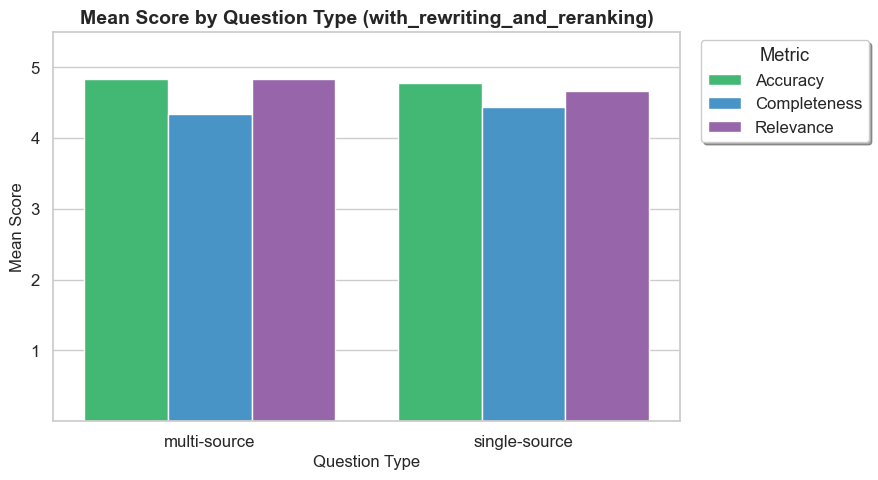

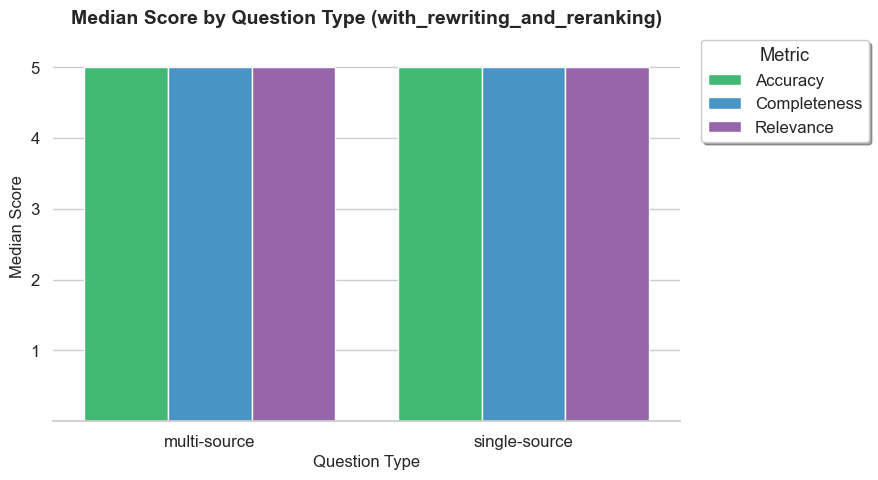

In [16]:
# Performance by question type (using best experiment)
best_name = df_summary.loc[df_summary["overall_score"].idxmax(), "experiment"]
best_records = all_results[best_name]

scores_by_type = defaultdict(lambda: {"accuracy": [], "completeness": [], "relevance": []})
for r in best_records:
    qt = r.get("question_type", "unknown")
    scores_by_type[qt]["accuracy"].append(r.get("accuracy", 0))
    scores_by_type[qt]["completeness"].append(r.get("completeness", 0))
    scores_by_type[qt]["relevance"].append(r.get("relevance", 0))

types = sorted(scores_by_type.keys())
metrics = ["accuracy", "completeness", "relevance"]
metric_labels = ["Accuracy", "Completeness", "Relevance"]

# Mean plot
mean_rows = []
for qt in types:
    for m, label in zip(metrics, metric_labels):
        data = scores_by_type[qt][m]
        mean_score = np.mean(data) if len(data) > 0 else np.nan
        mean_rows.append({"Question Type": qt, "Metric": label, "Mean Score": mean_score})
df_mean = pd.DataFrame(mean_rows)

sns.set_theme(style="whitegrid", font_scale=1.1)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df_mean, x="Question Type", y="Mean Score", hue="Metric",
    palette={"Accuracy": "#2ecc71", "Completeness": "#3498db", "Relevance": "#9b59b6"}, capsize=0.1)
ax.set_ylabel("Mean Score", fontsize=12)
ax.set_xlabel("Question Type", fontsize=12)
ax.set_title(f"Mean Score by Question Type ({best_name})", fontsize=14, fontweight="bold")
ax.set_ylim(0, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.legend(title="Metric", frameon=True, fancybox=True, shadow=True, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

# Median plot
median_rows = []
for qt in types:
    for m, label in zip(metrics, metric_labels):
        data = scores_by_type[qt][m]
        if len(data) > 0:
            median_score = np.median(data)
        else:
            median_score = np.nan
        median_rows.append({"Question Type": qt, "Metric": label, "Median Score": median_score})
df_median = pd.DataFrame(median_rows)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=df_median, 
    x="Question Type", 
    y="Median Score",
    hue="Metric", 
    palette={"Accuracy": "#2ecc71", "Completeness": "#3498db", "Relevance": "#9b59b6"},
    capsize=0.1
)
ax.set_ylabel("Median Score", fontsize=12)
ax.set_xlabel("Question Type", fontsize=12)
ax.set_title(f"Median Score by Question Type ({best_name})", fontsize=14, fontweight="bold")
ax.set_ylim(0, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.legend(title="Metric", frameon=True, fancybox=True, shadow=True, loc="upper left", bbox_to_anchor=(1.02, 1))
sns.despine(left=True)
plt.tight_layout()
plt.show()